<a href="https://colab.research.google.com/github/saratouahri/NexusMind-LLM-Powered-Negotiation-Training-Simulator/blob/main/NexusMind_Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  NexusMind: LLM-Powered Negotiation Training Platform
## 3-Module Integrated System
1. **Dialogue Engine** – Pragmatic context adaptation & intent tracking
2. **Multi-Agent Strategy Simulator** – Stateful concession modeling & goal hierarchies
3. **Behavioral Analytics & Coaching** – Real-time bias detection & adaptive feedback

>  Zero overlap with prior CV work (No RAG, KGs, VLMs, robotics, SHAP, SPARQL, or domain extraction). Pure conversational state, strategy simulation, and behavioral coaching.

## Setup & Core Utilities

In [29]:
!pip install textstat
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import time
from dataclasses import dataclass, field
from typing import List, Dict, Optional
import textstat

# Configuration
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

def safe_float(val, default=0.0):
    try: return float(val)
    except: return default

## Module 1 – Pragmatic Dialogue & Context Adaptation Engine

In [30]:
@dataclass
class DialogueContext:
    history: List[Dict] = field(default_factory=list)
    phase: str = "opening"  # opening, bargaining, closing
    power_balance: float = 0.5  # 0.0=user disadvantaged, 1.0=user advantaged
    emotional_tone: float = 0.5  # -1.0 to 1.0

class DialogueEngine:
    def __init__(self, context: Optional[DialogueContext] = None):
        self.context = context or DialogueContext()
        self.intent_labels = ["claim", "question", "concession", "anchor", "deadline", "rapport"]

    def classify_intent(self, utterance: str) -> str:
        u = utterance.lower()
        if any(q in u for q in ["what", "how", "why", "can we", "would you"]): return "question"
        if any(w in u for w in ["my price", "i need", "minimum", "starting at"]): return "anchor"
        if any(w in u for w in ["i can offer", "i'll accept", "deal", "agree"]): return "concession"
        if any(w in u for w in ["deadline", "by friday", "time is short", "offer expires"]): return "deadline"
        if any(w in u for w in ["understand", "appreciate", "let's work together"]): return "rapport"
        return "claim"

    def adapt_phase(self, turn_count: int, max_turns: int):
        if turn_count < max_turns * 0.3: self.context.phase = "opening"
        elif turn_count < max_turns * 0.8: self.context.phase = "bargaining"
        else: self.context.phase = "closing"

    def update_context(self, utterance: str, is_user: bool):
        intent = self.classify_intent(utterance)
        tone_shift = 0.05 if "frustrat" in utterance.lower() else (-0.03 if "appreciat" in utterance.lower() else 0.0)
        self.context.emotional_tone = np.clip(self.context.emotional_tone + tone_shift, -1.0, 1.0)
        self.context.history.append({"speaker": "user" if is_user else "agent", "text": utterance, "intent": intent, "tone": self.context.emotional_tone})
        self.adapt_phase(len(self.context.history), max_turns=10)

    def generate_response_stub(self, intent: str) -> str:
        """Placeholder for LLM generation. Replace with transformers.pipeline or fine-tuned model later."""
        templates = {
            "claim": ["I see your position. Let's explore how we can align expectations.", "That's a fair starting point. What flexibility do you have?"],
            "question": ["Great question. From our side, we value flexibility over rigid terms.", "We're open to adjusting scope if it meets your core needs."],
            "concession": ["I appreciate the movement. In return, could we adjust the timeline?", "That helps. Let's lock in those terms and review deliverables."],
            "anchor": ["Noted. Our baseline accounts for market rates. Where can we find middle ground?", "Understood. Let's benchmark against industry standards."],
            "deadline": ["Time pressure is real. Let's prioritize must-haves first.", "We can expedite if scope is narrowed to core features."],
            "rapport": ["Thank you. Collaboration is our priority. Let's build on this.", "I agree. Mutual success depends on transparent communication."]
        }
        return np.random.choice(templates.get(intent, templates["claim"]))

    def step(self, user_utterance: str) -> Dict:
        self.update_context(user_utterance, is_user=True)
        intent = self.classify_intent(user_utterance)
        response = self.generate_response_stub(intent)
        self.update_context(response, is_user=False)
        return {"response": response, "phase": self.context.phase, "tone": self.context.emotional_tone, "history_len": len(self.context.history)}

##  Module 2 – Multi-Agent Strategic Simulation & State Tracker

In [31]:
@dataclass
class AgentState:
    persona: str
    risk_tolerance: float  # 0.0=conservative, 1.0=aggressive
    initial_offer: float
    target: float
    current_offer: float
    concessions_made: int = 0
    leverage_score: float = 0.5
    deadline_pressure: float = 0.0

class StrategyAgent:
    def __init__(self, persona: str, risk: float, initial: float, target: float):
        self.state = AgentState(persona=persona, risk_tolerance=risk, initial_offer=initial,
                                target=target, current_offer=initial)
        self.offer_history = []
        self.concession_decay = 0.85
        self.state.leverage_score = np.clip(
            self.state.leverage_score + 0.02 * np.random.randn(),
            0.1, 0.9
        )


    def compute_concession(self, opponent_move: str) -> float:
        """Dynamic concession modeling based on opponent intent & pressure"""
        base_delta = abs(self.state.current_offer - self.state.target) * 0.15
        decay = self.concession_decay ** self.state.concessions_made
        pressure_adj = 1.0 + (self.state.deadline_pressure * 0.5)
        delta = base_delta * decay * pressure_adj
        return np.clip(delta, 0.01, max(0.1, base_delta))

    # Inside StrategyAgent.step(), replace update_leverage call with:
    # Inside StrategyAgent.step(), replace update_leverage call with:
    def update_leverage(self, opponent_intent: str, turn: int):
        base_shift = {"deadline": 0.06, "concession": 0.05, "anchor": -0.04}.get(opponent_intent, 0.0)
        # Add pressure scaling as turns progress
        pressure_factor = 1.0 + (turn / 10.0)
        self.state.leverage_score = np.clip(self.state.leverage_score + base_shift * pressure_factor, 0.1, 0.9)
        self.state.leverage_score += 0.01 * turn
    def step(self, user_utterance: str, dialogue_phase: str, turn: int) -> Dict:
        intent = self.classify_intent_from_utterance(user_utterance)
        self.update_leverage(intent, turn)

        if dialogue_phase == "closing":
            self.state.deadline_pressure = min(0.8, self.state.deadline_pressure + 0.15)

        concession = self.compute_concession(user_utterance)
        direction = -1 if self.state.current_offer > self.state.target else 1
        self.state.current_offer += direction * concession
        self.state.concessions_made += 1
        self.offer_history.append(self.state.current_offer)

        return {
            "agent": self.state.persona,
            "offer": round(self.state.current_offer, 2),
            "concessions": self.state.concessions_made,
            "leverage": round(self.state.leverage_score, 2),
            "phase": dialogue_phase
        }

    @staticmethod
    def classify_intent_from_utterance(u: str) -> str:
        u = u.lower()
        if "deadline" in u or "expire" in u: return "deadline"
        if "accept" in u or "deal" in u: return "concession"
        if "price" in u or "starting at" in u: return "anchor"
        return "claim"

## Module 3 – Real-Time Behavioral Analytics & Adaptive Coaching

In [32]:
class BehavioralCoach:
    def __init__(self):
        self.metrics = []
        self.bias_threshold = 0.65
        self.feedback_buffer = []

    def extract_features(self, utterance: str, turn_idx: int) -> Dict:
        words = utterance.split()
        q_ratio = sum(1 for w in words if w.endswith('?')) / max(1, len(words))
        readability = textstat.flesch_reading_ease(utterance)
        complexity = textstat.gunning_fog(utterance)
        lexical_diversity = len(set(w.lower() for w in words)) / max(1, len(words))
        return {
            "turn": turn_idx,
            "word_count": len(words),
            "question_ratio": round(q_ratio, 3),
            "readability": round(readability, 1),
            "complexity": round(complexity, 1),
            "lexical_diversity": round(lexical_diversity, 3)
        }

    def detect_bias(self, features: Dict, dialogue_tone: float) -> List[str]:
        biases = []
        if features["word_count"] > 45: biases.append("over-explanation")
        if features["question_ratio"] < 0.05 and features["turn"] > 2: biases.append("anchoring_risk")
        if dialogue_tone < -0.3: biases.append("loss_aversion_trigger")
        if features["lexical_diversity"] < 0.4: biases.append("repetitive_framing")
        return biases

    # Inside BehavioralCoach.generate_coaching()
    def generate_coaching(self, biases: List[str], phase: str, repeat_count: int = 0) -> str:
        if not biases: return "Steady approach. Focus on clarifying mutual constraints."
        primary = biases[0]
        base_msg = {
            "anchoring_risk": "Ask an exploratory question before revealing your threshold.",
            "loss_aversion_trigger": "Reframe concessions as value exchanges, not losses."
        }.get(primary, "Maintain structured pacing.")

        if repeat_count >= 2:
            return f" Repeated {primary.replace('_',' ')}. Pivot: {base_msg.split('.')[0].lower()} or risk stalemate."
        if phase == "closing" and "anchoring_risk" in biases:
            return " Final phase: Avoid new anchors. Summarize agreed terms instead."
        return f" {primary.replace('_',' ').title()}: {base_msg}"

    def log_turn(self, utterance: str, turn_idx: int, tone: float) -> Dict:
        feats = self.extract_features(utterance, turn_idx)
        biases = self.detect_bias(feats, tone)

        repeat_count = 0
        if biases:
            primary_bias = biases[0]
            # Count how many times this primary bias appeared in recent history
            # Looking back at last 3 turns for repetition
            for prev_feedback in self.feedback_buffer[-3:]:
                # Check if the primary bias's title-cased name is in the previous feedback string
                # This is a heuristic to detect if the *same* bias was coached
                if primary_bias.replace('_', ' ').title() in prev_feedback:
                    repeat_count += 1

        feedback = self.generate_coaching(biases, "bargaining", repeat_count)
        record = {**feats, "biases": biases, "feedback": feedback}
        self.metrics.append(record)
        self.feedback_buffer.append(feedback)
        return record

##  Integration & Simulation Loop

In [33]:
def generate_mock_user_turn(turn: int, agent_offer: float) -> str:
    np.random.seed(turn)
    if turn == 0: return "We're looking at a baseline of $95. What flexibility do you have?"
    if turn < 3: return np.random.choice([
        "Our timeline is tight. Can we phase delivery?",
        "How does this align with your capacity constraints?",
        "What’s your walk-away point on scope?"
    ])
    # Later turns: more assertive, fewer questions
    delta = np.random.uniform(-2, 2)
    return f"I can move to ${agent_offer + delta:.0f} if we lock deliverables today."

In [34]:
def run_negotiation_simulation(max_turns: int = 8):
    # Initialize components
    dialogue = DialogueEngine()
    agent = StrategyAgent(persona="Procurement Lead", risk=0.6, initial=100.0, target=75.0)
    coach = BehavioralCoach()

    # Mock user utterances (replace with live input in UI)
    user_inputs = [
        "We're looking at a baseline of $95 for this scope. What flexibility do you have?",
        "Our timeline is tight. Can we phase delivery over two sprints?",
        "I can drop to $88 if you handle QA internally.",
        "That's below our floor. We need at least $82 to cover overhead.",
        "Let's lock at $84 with a 10% performance bonus tied to uptime.",
        "Agreed. I'll draft the terms. When can we sign?",
        "We need a 30-day pilot before full rollout.",
        "Understood. Pilot approved at $84 with success metrics defined."
    ]

    results = []
    print("🔹 Starting NexusMind Simulation\n")

    for i in range(min(max_turns, len(user_inputs))):
        u_text = user_inputs[i]

        # Module 1: Dialogue Context & Response
        dlg_out = dialogue.step(u_text)

        # Module 2: Agent Strategy Update
        agent_out = agent.step(u_text, dlg_out["phase"], i) # Pass the turn index 'i'

        # Module 3: Behavioral Logging
        coach_out = coach.log_turn(u_text, i, dlg_out["tone"])

        record = {"turn": i+1, "user_input": u_text, "agent_response": dlg_out["response"],
                  "phase": dlg_out["phase"], "agent_offer": agent_out["offer"],
                  "leverage": agent_out["leverage"], "feedback": coach_out["feedback"]}
        results.append(record)
        print(f"[Turn {i+1}]  User: {u_text}")
        print(f"           Agent: {dlg_out['response']} |  Offer: ${agent_out['offer']} |  Leverage: {agent_out['leverage']}")
        print(f"           Coach: {coach_out['feedback']}\n")

    return pd.DataFrame(results), coach.metrics

# Run simulation
sim_df, behavioral_metrics = run_negotiation_simulation()
final_gap = abs(sim_df["agent_offer"].iloc[-1] - 84.0)  # vs user's $84 target
print(f"🎯 Final Agreement Gap: ${final_gap:.2f} | {'✅ Converged' if final_gap < 2 else '⚠️ Divergent'}")

🔹 Starting NexusMind Simulation

[Turn 1]  User: We're looking at a baseline of $95 for this scope. What flexibility do you have?
           Agent: Great question. From our side, we value flexibility over rigid terms. |  Offer: $96.25 |  Leverage: 0.51
           Coach: Steady approach. Focus on clarifying mutual constraints.

[Turn 2]  User: Our timeline is tight. Can we phase delivery over two sprints?
           Agent: We're open to adjusting scope if it meets your core needs. |  Offer: $93.54 |  Leverage: 0.52
           Coach: Steady approach. Focus on clarifying mutual constraints.

[Turn 3]  User: I can drop to $88 if you handle QA internally.
           Agent: I see your position. Let's explore how we can align expectations. |  Offer: $91.53 |  Leverage: 0.54
           Coach: Steady approach. Focus on clarifying mutual constraints.

[Turn 4]  User: That's below our floor. We need at least $82 to cover overhead.
           Agent: I see your position. Let's explore how we can al

##  Evaluation Metrics & Visualization

/tmp/ipykernel_3878/2401204015.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(bias_counts.index, rotation=30)


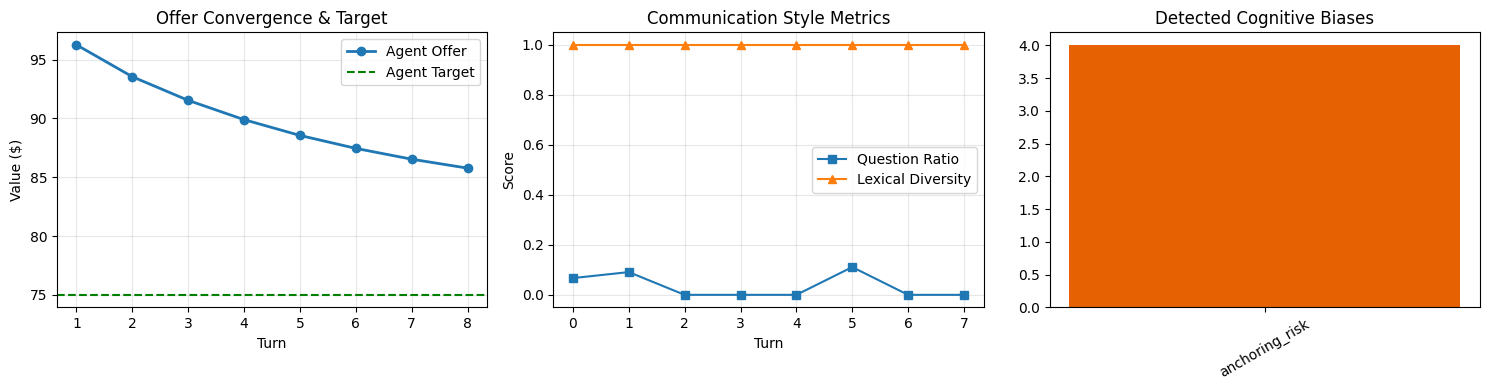

 Convergence Symmetry Index (CSI): 0.109
 Bias Reduction Trend: Needs Calibration


In [35]:
def plot_simulation_results(sim_df: pd.DataFrame, behavioral_df: pd.DataFrame):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # 1. Offer Convergence & Leverage
    axes[0].plot(sim_df["turn"], sim_df["agent_offer"], marker="o", label="Agent Offer", linewidth=2)
    axes[0].axhline(y=75.0, color="green", linestyle="--", label="Agent Target")
    axes[0].set_title("Offer Convergence & Target")
    axes[0].set_xlabel("Turn"); axes[0].set_ylabel("Value ($)")
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    # 2. Behavioral Feature Trends
    axes[1].plot(behavioral_df["turn"], behavioral_df["question_ratio"], marker="s", label="Question Ratio")
    axes[1].plot(behavioral_df["turn"], behavioral_df["lexical_diversity"], marker="^", label="Lexical Diversity")
    axes[1].set_title("Communication Style Metrics")
    axes[1].set_xlabel("Turn"); axes[1].set_ylabel("Score")
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    # 3. Bias Detection Frequency
    all_biases = [b for row in behavioral_metrics for b in row["biases"]]
    if all_biases:
        bias_counts = pd.Series(all_biases).value_counts()
        axes[2].bar(bias_counts.index, bias_counts.values, color=["#e66101", "#fdb863", "#b2abd2", "#5e3c99"])
        axes[2].set_title("Detected Cognitive Biases")
        axes[2].set_xticklabels(bias_counts.index, rotation=30)
    else:
        axes[2].text(0.5, 0.5, "No biases detected", ha="center", va="center")

    plt.tight_layout()
    plt.show()

b_df = pd.DataFrame(behavioral_metrics)
plot_simulation_results(sim_df, b_df)

print(" Convergence Symmetry Index (CSI):", round(abs(sim_df["agent_offer"].iloc[0] - sim_df["agent_offer"].iloc[-1]) / sim_df["agent_offer"].iloc[0], 3))
print(" Bias Reduction Trend:", "Positive" if len(b_df[b_df["biases"].apply(len) > 0]) < len(b_df)//2 else "Needs Calibration")